In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import cartopy.crs as ccrs
import cmocean.cm as cmo
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import xarray as xr

from jaxparrow.cyclogeostrophy import cyclogeostrophic_imbalance, gradient_wind, minimization_based
from jaxparrow.utils import kinematics, operators


jax.config.update("jax_enable_x64", True)

This notebook demonstrates how regularization can be added to the minimization-based formulation of the cyclogeostrophic inversion problem.

## SWOT observation

We use the filtered $u$ and $v$ component of the geostrophic currents, distributed in version 3.0 of the product from Aviso. And we focus for the illustration on the Balearic Sea.

In [ ]:
def make_da(data):
    return xr.DataArray(
        data, coords=swot_003_ds.ssha_filtered.coords, dims=swot_003_ds.ssha_filtered.dims
    )


def get_med_sea(swot_ds):
    med_mask = (
        (swot_ds["latitude"] > 30.0681) & (swot_ds["latitude"] < 47.3764) & 
        (swot_ds["longitude"] > -6.0326) & (swot_ds["longitude"] < 42.355)
    )
    swot_ds = swot_ds.where(med_mask, drop=True)

    sea_mask = ~np.isnan(swot_ds["ssha_filtered"])
    min_lat, max_lat = swot_ds["latitude"].where(sea_mask).min(), swot_ds["latitude"].where(sea_mask).max()
    min_lon, max_lon = swot_ds["longitude"].where(sea_mask).min(), swot_ds["longitude"].where(sea_mask).max()
    
    swot_ds = swot_ds.where(
        (swot_ds["latitude"] >= min_lat) & (swot_ds["latitude"] <= max_lat) &
        (swot_ds["longitude"] >= min_lon) & (swot_ds["longitude"] <= max_lon),
        drop=True
    )

    return swot_ds


swot_003_ds = xr.open_dataset("data/SWOT/SWOT_L3_LR_SSH_Expert_506_003_20230429T184429_20230429T193535_v3.0.nc")
swot_003_ds = get_med_sea(swot_003_ds)

lat = jnp.asarray(swot_003_ds.latitude.values)
lon = jnp.asarray(swot_003_ds.longitude.values)
ug = jnp.asarray(swot_003_ds.ugos_filtered.values)
vg = jnp.asarray(swot_003_ds.vgos_filtered.values)

In [5]:
uvg_da = (swot_003_ds.ugos_filtered**2 + swot_003_ds.vgos_filtered**2)**0.5

rvg = kinematics.vorticity(ug, vg, lat, lon)
rvg_da = make_da(rvg)

cg_uimb_g, cg_vimb_g = cyclogeostrophic_imbalance(ug, vg, ug, vg, lat, lon)
cg_imb_g = (cg_uimb_g**2 + cg_vimb_g**2)**0.5
cg_imb_g_da = make_da(cg_imb_g)

We can see that in the version 3.0 geostrophic currents are relatively smooth, and do not look too contaminated by noise and/or unbalanced signal.

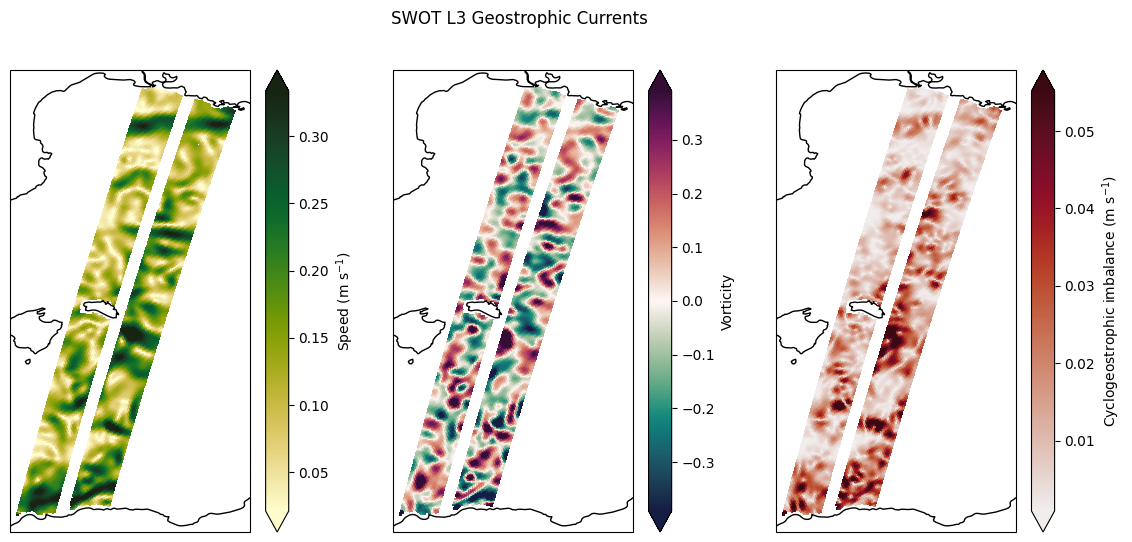

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6), subplot_kw={"projection": ccrs.PlateCarree()})

_ = uvg_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.speed, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Speed (m s$^{-1}$)"},
    transform=ccrs.PlateCarree(), ax=axes[0]
)

_ = rvg_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.curl, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Vorticity"},
    transform=ccrs.PlateCarree(), ax=axes[1]
)

_ = cg_imb_g_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.amp, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Cyclogeostrophic imbalance (m s$^{-1}$)"},
    transform=ccrs.PlateCarree(), ax=axes[2]
)

for ax in axes:
    ax.coastlines()

fig.suptitle("SWOT L3 Geostrophic Currents")

plt.show()

Howerver, when looking at the cyclogeostrophic currents estimated using the [`gradient_wind`](../api.md#jaxparrow.cyclogeostrophy.gradient_wind) method we can notice empty areas, where the azimuthal cyclogeostrophic equation does not have a physical solution.

In [7]:
gw_results = gradient_wind(lat_t=lat, lon_t=lon, ug_t=ug, vg_t=vg)

ucg_gw = gw_results.ucg
vcg_gw = gw_results.vcg

uvcg_gw = kinematics.magnitude(ucg_gw, vcg_gw)
rvcg_gw = kinematics.vorticity(ucg_gw, vcg_gw, lat, lon)

uvcg_gw_da = make_da(uvcg_gw)
rvcg_gw_da = make_da(rvcg_gw)

cg_uimb_gw, cg_vimb_gw = cyclogeostrophic_imbalance(ug, vg, ucg_gw, vcg_gw, lat, lon)
cg_imb_gw = (cg_uimb_gw**2 + cg_vimb_gw**2)**0.5
cg_imb_gw_da = make_da(cg_imb_gw)

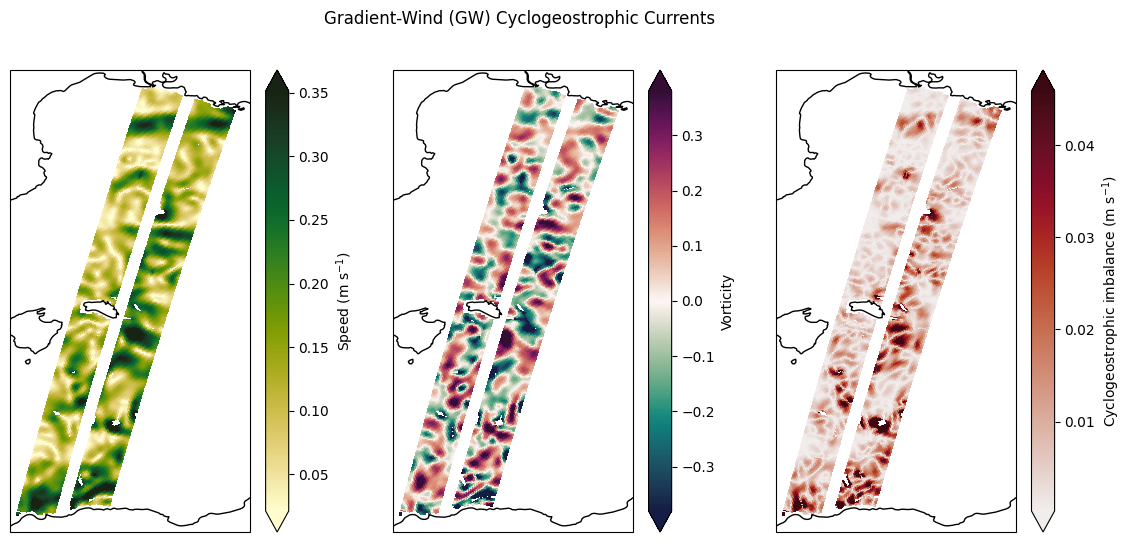

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6), subplot_kw={"projection": ccrs.PlateCarree()})

_ = uvcg_gw_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.speed, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Speed (m s$^{-1}$)"},
    transform=ccrs.PlateCarree(), ax=axes[0]
)

_ = rvcg_gw_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.curl, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Vorticity"},
    transform=ccrs.PlateCarree(), ax=axes[1]
)

_ = cg_imb_gw_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.amp, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Cyclogeostrophic imbalance (m s$^{-1}$)"},
    transform=ccrs.PlateCarree(), ax=axes[2]
)

for ax in axes:
    ax.coastlines()

fig.suptitle("Gradient-Wind (GW) Cyclogeostrophic Currents")

plt.show()

And in those regions, the [`minimization_based`](../api.md#jaxparrow.cyclogeostrophy.minimization_based) fields presents some suspicious patterns.
But with this approach, we can also add a regularization term to the loss function being minimized!

In [9]:
mb_results = minimization_based(
    lat_t=lat, lon_t=lon, ug_t=ug, vg_t=vg,
    optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3))
)

ucg_mb = mb_results.ucg
vcg_mb   = mb_results.vcg

uvcg_mb = kinematics.magnitude(ucg_mb, vcg_mb)
rvcg_mb = kinematics.vorticity(ucg_mb, vcg_mb, lat, lon)

uvcg_mb_da = make_da(uvcg_mb)
rvcg_mb_da = make_da(rvcg_mb)

cg_uimb_mb, cg_vimb_mb = cyclogeostrophic_imbalance(ug, vg, ucg_mb, vcg_mb, lat, lon)
cg_imb_mb = (cg_uimb_mb**2 + cg_vimb_mb**2)**0.5
cg_imb_mb_da = make_da(cg_imb_mb)

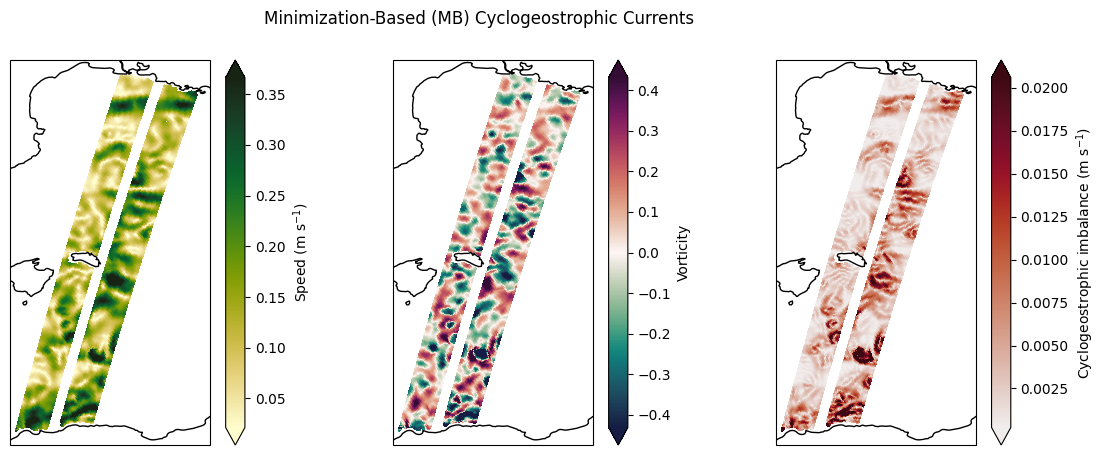

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), subplot_kw={"projection": ccrs.PlateCarree()})

_ = uvcg_mb_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.speed, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Speed (m s$^{-1}$)"},
    transform=ccrs.PlateCarree(), ax=axes[0]
)

_ = rvcg_mb_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.curl, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Vorticity"},
    transform=ccrs.PlateCarree(), ax=axes[1]
)

_ = cg_imb_mb_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.amp, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Cyclogeostrophic imbalance (m s$^{-1}$)"},
    transform=ccrs.PlateCarree(), ax=axes[2]
)

for ax in axes:
    ax.coastlines()

fig.suptitle("Minimization-Based (MB) Cyclogeostrophic Currents")

plt.show()

## Regularization

Adding a regularization term simply resolves to writing a JAX-friendly regularization function. 
The signature (i.e. the parameters) of the regularization function must contain ``ucg_t`` and ``vcg_t`` as arguments for the components of the cyclogeostrophic velocity field, and ``lat_t`` and ``lon_t`` as arguments for the grid coordinate arrays. We can also provide some additional arguments, such as ``dx_t``, ``dy_t``, and ``land_mask`` to avoid recomputing them at every minimization step, but those are not mandatory.
The order of the arguments does not matter, but their exact spelling does. We refer the reader to the API documentation of the [`minimization_based`](../api.md#jaxparrow.cyclogeostrophy.minimization_based) function for the comprehensive description of the possible signature of the regularization function.

Here we use a biharmonic-like regularization on the horizontal gradients of the vorticity. For this we use the [`vorticity`](../api.md#jaxparrow.kinematics.vorticity) and [`horizontal_derivatives`](../api.md#jaxparrow.operators.horizontal_derivatives) functions of the package.

In [11]:
lambda_reg = 0.01

def biharmonic_regularization(ucg_t, vcg_t, lat_t, lon_t, dx_t, dy_t, land_mask):
    vort = kinematics.vorticity(ucg_t, vcg_t, lat_t, lon_t)
    dvort_x, dvort_y = operators.horizontal_derivatives(vort, dx=dx_t, dy=dy_t, land_mask=land_mask)
    return lambda_reg * jnp.nansum((dvort_x * dx_t)**2 + (dvort_y * dy_t)**2)

We then pass this function as an argument to [`minimization_based`](../api.md#jaxparrow.cyclogeostrophy.minimization_based) when performing the inversion.

In [12]:
mb_reg_results = minimization_based(
    lat_t=lat, lon_t=lon, ug_t=ug, vg_t=vg, 
    optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3)), 
    regularization=biharmonic_regularization
)

The result is visually very similar to the solution obtain without the regularization, but when looking closely we can notice some differences.

In [13]:
ucg_mb_reg = mb_reg_results.ucg
vcg_mb_reg = mb_reg_results.vcg

uvcg_mb_reg = kinematics.magnitude(ucg_mb_reg, vcg_mb_reg)
rvcg_mb_reg = kinematics.vorticity(ucg_mb_reg, vcg_mb_reg, lat, lon)

uvcg_mb_reg_da = make_da(uvcg_mb_reg)
rvcg_mb_reg_da = make_da(rvcg_mb_reg)

cg_uimb_mb_reg, cg_vimb_mb_reg = cyclogeostrophic_imbalance(ug, vg, ucg_mb_reg, vcg_mb_reg, lat, lon)
cg_imb_mb_reg = (cg_uimb_mb_reg**2 + cg_vimb_mb_reg**2)**0.5
cg_imb_mb_reg_da = make_da(cg_imb_mb_reg)

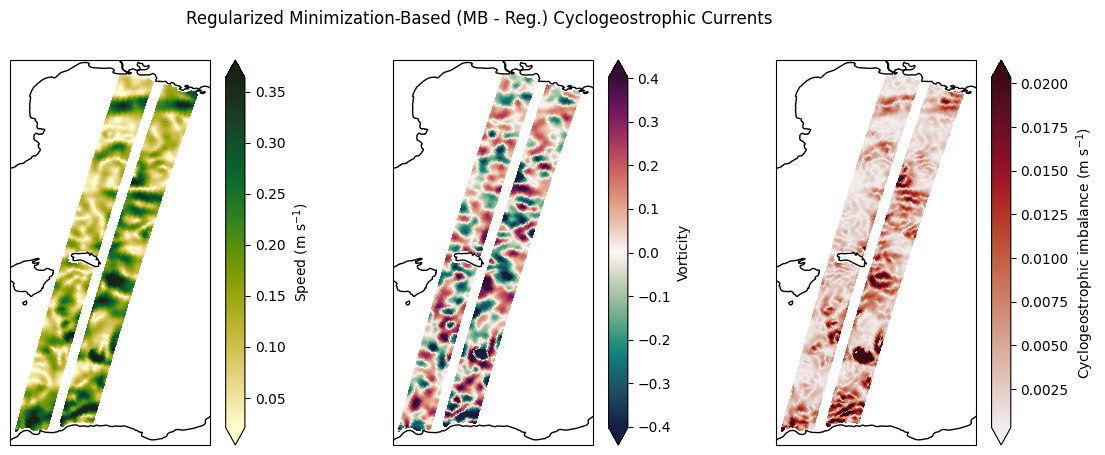

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), subplot_kw={"projection": ccrs.PlateCarree()})

_ = uvcg_mb_reg_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.speed, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Speed (m s$^{-1}$)"},
    transform=ccrs.PlateCarree(), ax=axes[0]
)

_ = rvcg_mb_reg_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.curl, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Vorticity"},
    transform=ccrs.PlateCarree(), ax=axes[1]
)

_ = cg_imb_mb_reg_da.plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.amp, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Cyclogeostrophic imbalance (m s$^{-1}$)"},
    transform=ccrs.PlateCarree(), ax=axes[2]
)

for ax in axes:
    ax.coastlines()

fig.suptitle("Regularized Minimization-Based (MB - Reg.) Cyclogeostrophic Currents")

plt.show()

## Comparison

To better observe the qualitative differences between the different inversion results, we can visualize the difference of the fieds in addition to the fields themselfs.

In [ ]:
methods = ["Geos.", "GW", "MB", "MB - Reg."]

row_labels = methods[:-1]  # subtracted from
col_labels = methods[1:]   # subtracted


def build_diff_da(fields):
    diff_data = np.full((len(row_labels), len(col_labels)) + fields[0].shape, np.nan)
    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            if i <= j:  # upper triangle
                diff_data[i, j] = np.array(fields[j + 1] - fields[i])
    return xr.DataArray(
        diff_data,
        dims=("row", "col", "num_lines", "num_pixels"),
        coords={
            "row": row_labels, "col": col_labels,
            "latitude": (("num_lines", "num_pixels"), swot_003_ds["latitude"].values),
            "longitude": (("num_lines", "num_pixels"), swot_003_ds["longitude"].values),
        },
    )


def plot_diff_triangle(da, cmap, cbar_label):
    fg = da.plot.pcolormesh(
        x="longitude", y="latitude", row="row", col="col",
        cmap=cmap, robust=True, add_colorbar=True,
        cbar_kwargs={"label": cbar_label, "aspect": 50},
        figsize=(10, 12),
        subplot_kws={"projection": ccrs.PlateCarree()},
    )
    fg.set_titles("{value}")
    for i, ax in enumerate(fg.axs.flat):
        row_idx, col_idx = divmod(i, len(col_labels))
        if row_idx > col_idx:
            ax.set_visible(False)
        else:
            ax.coastlines()
    plt.show()


uvcg_diff_da = build_diff_da([uvg_da, uvcg_gw_da, uvcg_mb_da, uvcg_mb_reg_da])
rv_diff_da = build_diff_da([rvg_da, rvcg_gw_da, rvcg_mb_da, rvcg_mb_reg_da])
cg_imb_diff_da = build_diff_da([cg_imb_g_da, cg_imb_gw_da, cg_imb_mb_da, cg_imb_mb_reg_da])

In the speed difference fields of the regularization variant we now see more clearly small differences, particularly in the regions where the gradient-wind solution does not exist!

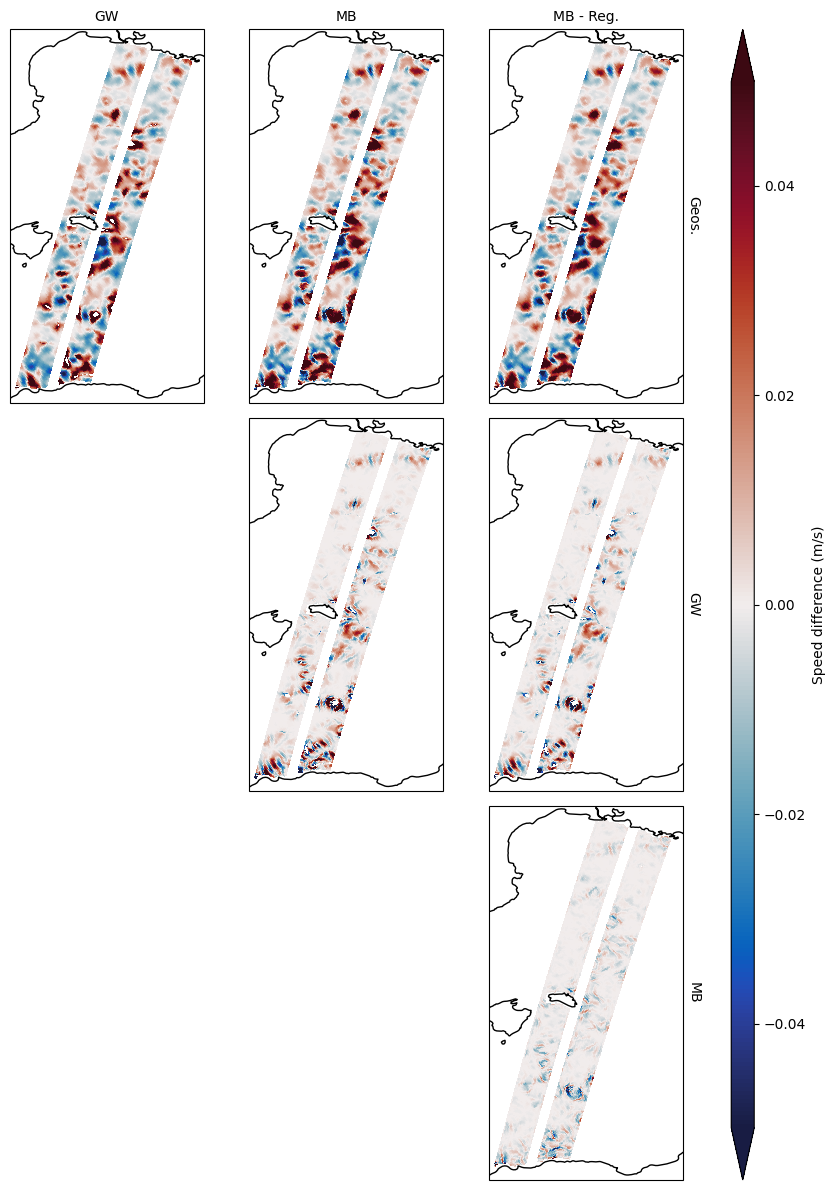

In [18]:
plot_diff_triangle(uvcg_diff_da, cmo.balance, "Speed difference (m/s)")

Those corrections are more pronounced in the vorticity fields, again in the areas where the gradient-wind reconstruction suggests that cyclogeostrophy is not valid.

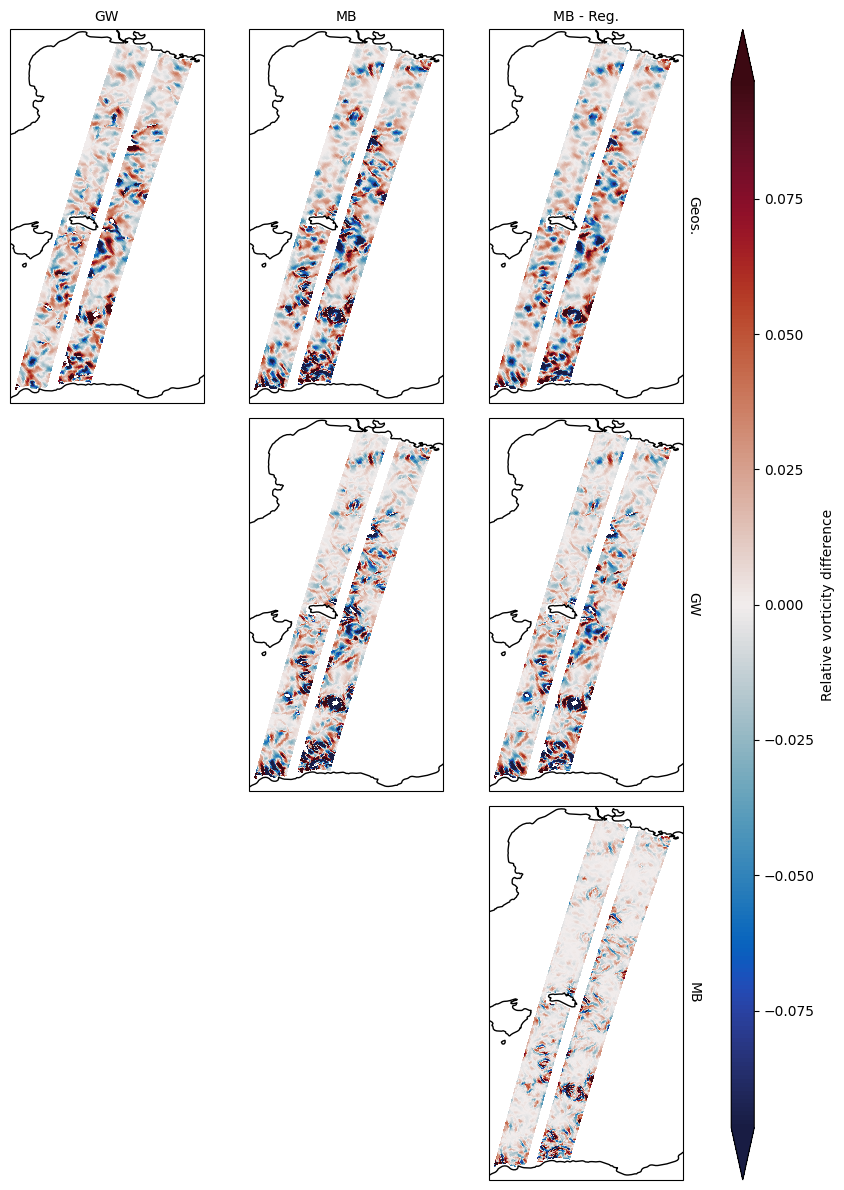

In [19]:
plot_diff_triangle(rv_diff_da, cmo.balance, "Relative vorticity difference")

Finaly, when looking at the cyclogeostrophic imbalance fields, we observe that in those problematic regions, the regularization can further reduce the minimization of the imbalance.

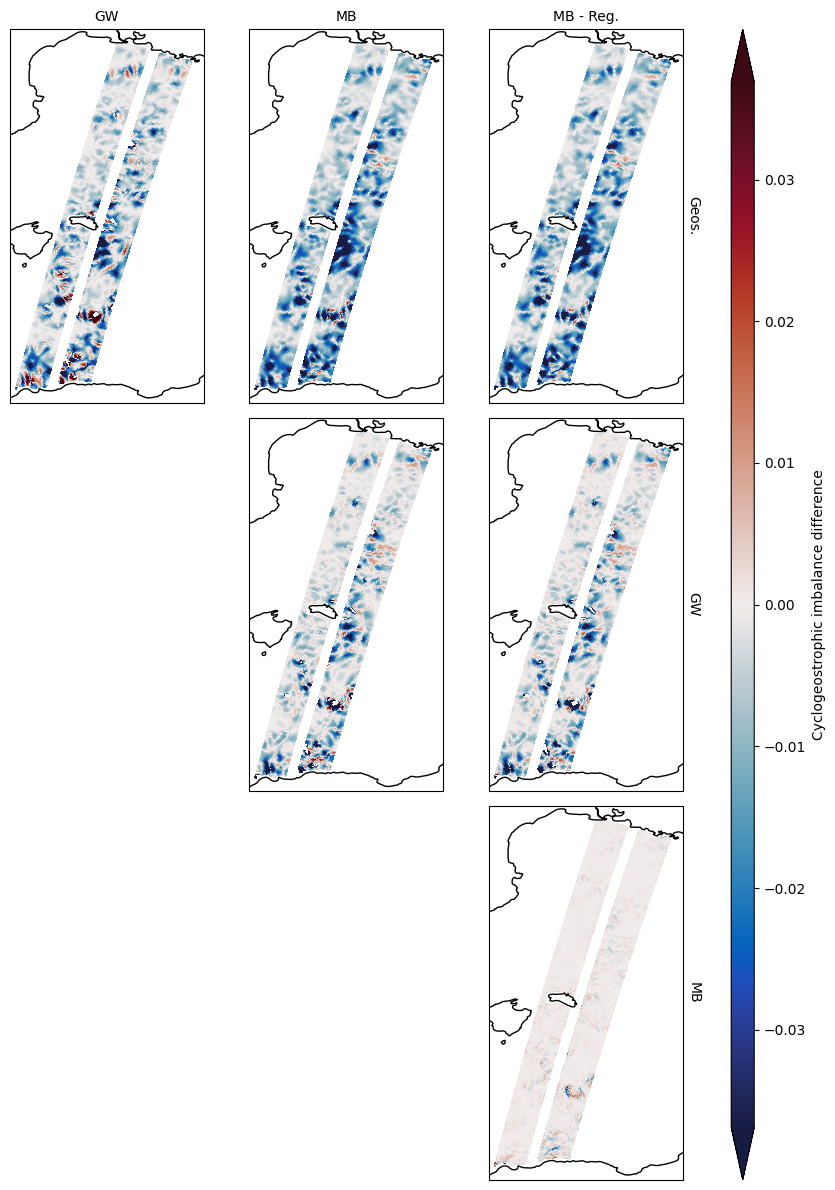

In [20]:
plot_diff_triangle(cg_imb_diff_da, cmo.balance, "Cyclogeostrophic imbalance difference")